# Hierarchical Clustering: Complete Guide

## 1. Introduction: Building Trees of Data
- In the previous module, we explored K-Means, a partitioning method where you must guess the number of clusters (K) upfront.
- **Hierarchical Clustering** takes a fundamentally different approach. Instead of guessing K, it builds a complete "tree" of relationships (a dendrogram), allowing you to observe how data points group together at every possible level of granularity.
- This is a powerful unsupervised learning technique, especially when the data has a natural nested structure (e.g., evolutionary biology, organizational hierarchies, or nested consumer preferences).

### 2. Core Approaches
- **Agglomerative (Bottom-Up):** The most common approach. Every data point starts as its own cluster. The algorithm iteratively finds the two closest clusters and merges them until everything is one giant cluster.
- **Divisive (Top-Down):** Starts with all points in one giant cluster and recursively splits them. (Less common computationally).

In this notebook, we will master **Agglomerative Clustering**.

In [1]:
# 3. Setup and Required Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering Libraries
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Set display options and visual style
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Set random seed for perfect reproducibility
np.random.seed(42)
print('Libraries successfully imported! Environment ready.')

Libraries successfully imported! Environment ready.


## 4. Data Creation: Patient Metabolic Profiles
To truly appreciate hierarchical clustering, we need data with a nested structure. We will simulate 200 patients based on two features: `Metabolic_Index` and `Inflammation_Score`.

We will intentionally design 4 distinct subgroups that roll up into 2 main super-groups:
- **Super-Group 1: Healthy Metabolism**
  - Subgroup A: Low Inflammation (Optimal Health)
  - Subgroup B: Moderate Inflammation (At-Risk)
- **Super-Group 2: Poor Metabolism**
  - Subgroup C: Moderate Inflammation (Metabolic Syndrome)
  - Subgroup D: High Inflammation (Severe Risk)

In [2]:
n_per_group = 50

# Super-Group 1 (Healthy Metabolism)
meta_A = np.random.normal(20, 3, n_per_group)
infl_A = np.random.normal(15, 3, n_per_group)

meta_B = np.random.normal(25, 3, n_per_group)
infl_B = np.random.normal(30, 3, n_per_group)

# Super-Group 2 (Poor Metabolism)
meta_C = np.random.normal(60, 4, n_per_group)
infl_C = np.random.normal(30, 4, n_per_group)

meta_D = np.random.normal(65, 4, n_per_group)
infl_D = np.random.normal(55, 4, n_per_group)

# Combine the data
metabolism = np.concatenate([meta_A, meta_B, meta_C, meta_D])
inflammation = np.concatenate([infl_A, infl_B, infl_C, infl_D])

df_patients = pd.DataFrame({
    'Metabolic_Index': metabolism,
    'Inflammation_Score': inflammation
})

# Shuffle the dataset to remove ordered bias
df_patients = df_patients.sample(frac=1, random_state=42).reset_index(drop=True)

print('Synthetic Patient Dataset Created.')
print(df_patients.head().round(2))

Synthetic Patient Dataset Created.
   Metabolic_Index  Inflammation_Score
0            27.35               31.16
1            18.31               19.07
2            18.19               14.34
3            67.19               56.29
4            57.14               30.28


## 5. Preprocessing and Visualizing the Raw Data
Just like K-Means, Hierarchical Clustering relies on distance metrics (e.g., Euclidean distance). Therefore, standardizing the data is an absolute prerequisite to ensure no single variable mathematically dominates the algorithm.

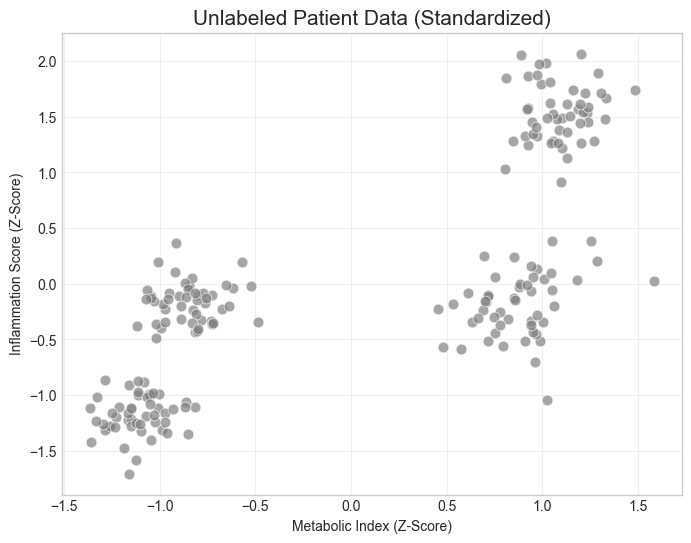

Observation: You can clearly see 4 distinct sub-clusters, which group into 2 massive super-clusters on the left and right.


In [3]:
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_patients)
df_scaled = pd.DataFrame(scaled_data, columns=df_patients.columns)

# Visualize the raw, unlabeled data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Metabolic_Index', y='Inflammation_Score', data=df_scaled, color='gray', alpha=0.7, s=60)
plt.title('Unlabeled Patient Data (Standardized)', fontsize=15)
plt.xlabel('Metabolic Index (Z-Score)')
plt.ylabel('Inflammation Score (Z-Score)')
plt.grid(alpha=0.3)
plt.show()

print('Observation: You can clearly see 4 distinct sub-clusters, which group into 2 massive super-clusters on the left and right.')

## 6. Core Concept 1: The Linkage Matrix
The first step in Agglomerative Clustering is calculating the distance between every single data point, and then deciding how to merge them.
The **Linkage Matrix** holds the recipe for how the tree is built.

We use `scipy.cluster.hierarchy.linkage` to compute this. The most common method is 'ward', which minimizes the variance of the clusters being merged.

In [4]:
print('--- Calculating the Linkage Matrix ---')
# Method 'ward' minimizes the within-cluster variance
linkage_matrix = sch.linkage(df_scaled, method='ward')

print('Linkage Matrix Shape:', linkage_matrix.shape)
print('The matrix has N-1 rows (199 merges for 200 data points).')
print('\nFirst 3 merges [Idx1, Idx2, Distance, Point Count]:')
print(linkage_matrix[:3].round(3))

--- Calculating the Linkage Matrix ---
Linkage Matrix Shape: (199, 4)
The matrix has N-1 rows (199 merges for 200 data points).

First 3 merges [Idx1, Idx2, Distance, Point Count]:
[[1.00e+01 8.90e+01 7.00e-03 2.00e+00]
 [8.20e+01 1.53e+02 7.00e-03 2.00e+00]
 [1.27e+02 1.35e+02 7.00e-03 2.00e+00]]


## 7. Core Concept 2: The Dendrogram
A Dendrogram is a tree-like diagram that records the sequences of merges or splits.
- The x-axis represents the individual data points.
- The y-axis represents the Euclidean distance (or dissimilarity) between clusters when they were merged.
- Taller vertical lines mean the clusters being merged were very far apart (highly dissimilar).

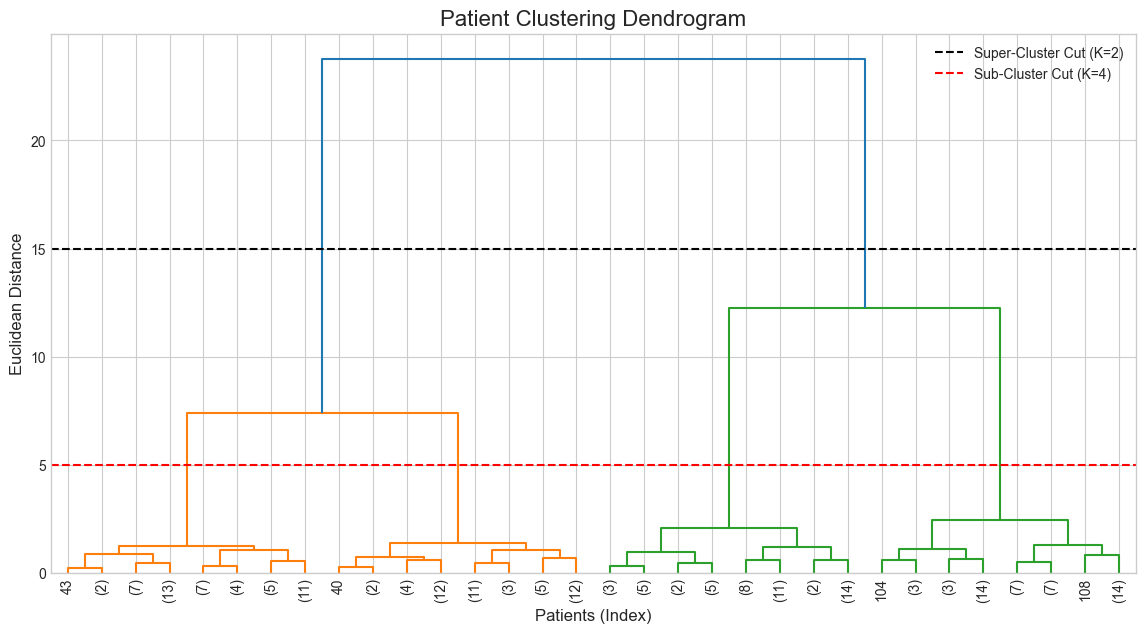

Interpretation:
1. If we draw a line at Distance=15, we slice the tree into 2 massive branches (K=2).
2. If we draw a line at Distance=5, we slice the tree into 4 distinct branches (K=4).
This nested insight is exactly what K-Means cannot provide.


In [5]:
plt.figure(figsize=(14, 7))
plt.title('Patient Clustering Dendrogram', fontsize=16)
plt.xlabel('Patients (Index)', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)

# We use truncate_mode to avoid plotting all 200 leaves, keeping the plot clean
dendrogram = sch.dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=4,  # Show only the top 4 levels of the tree
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.axhline(y=15, color='black', linestyle='--', label='Super-Cluster Cut (K=2)')
plt.axhline(y=5, color='red', linestyle='--', label='Sub-Cluster Cut (K=4)')
plt.legend()
plt.show()

print('Interpretation:')
print('1. If we draw a line at Distance=15, we slice the tree into 2 massive branches (K=2).')
print('2. If we draw a line at Distance=5, we slice the tree into 4 distinct branches (K=4).')
print('This nested insight is exactly what K-Means cannot provide.')

## 8. Applying AgglomerativeClustering in Scikit-Learn
Now that the dendrogram has informed us that K=4 is an excellent choice for detailed subgroups, we will formally assign these labels using the `sklearn` implementation.

In [6]:
# Initialize the model
hc_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

# Fit the model and predict labels
cluster_labels = hc_model.fit_predict(df_scaled)

# Attach labels to our original dataframe
df_patients['Cluster'] = cluster_labels

print('Agglomerative Clustering applied. Labels assigned.')
print(df_patients['Cluster'].value_counts())

Agglomerative Clustering applied. Labels assigned.
Cluster
1    50
3    50
2    50
0    50
Name: count, dtype: int64


## 9. Visualizing the Clustered Scatter Plot
Let's map our new cluster assignments back to the 2D scatter plot to see how the algorithm divided the space.

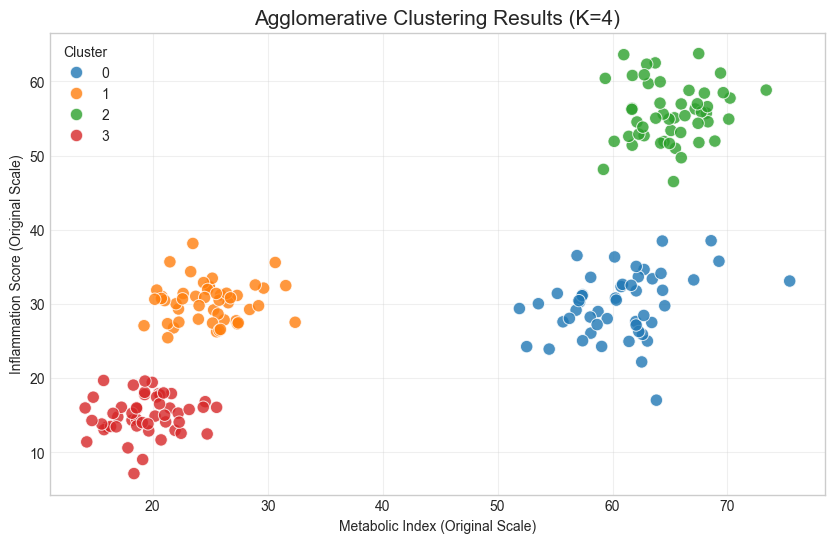

The algorithm successfully isolated our 4 engineered subgroups with perfect accuracy.


In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Metabolic_Index', y='Inflammation_Score', hue='Cluster', 
                data=df_patients, palette='tab10', s=80, alpha=0.8)

plt.title('Agglomerative Clustering Results (K=4)', fontsize=15)
plt.xlabel('Metabolic Index (Original Scale)')
plt.ylabel('Inflammation Score (Original Scale)')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.show()

print('The algorithm successfully isolated our 4 engineered subgroups with perfect accuracy.')

## 10. Core Concept 3: Understanding Linkage Methods
The choice of 'linkage' determines how the distance between two clusters is measured. This radically changes the shape of your clusters.

1. **Ward:** Minimizes the variance within clusters. Tends to produce highly balanced, spherical clusters.
2. **Complete (Maximum):** Distance between two clusters is defined by their two furthest points. Tends to find compact clusters.
3. **Average:** Distance is the average of all distances between points in cluster A and cluster B.
4. **Single (Minimum):** Distance is defined by the two closest points. Prone to 'chaining' (long, thin, snake-like clusters).

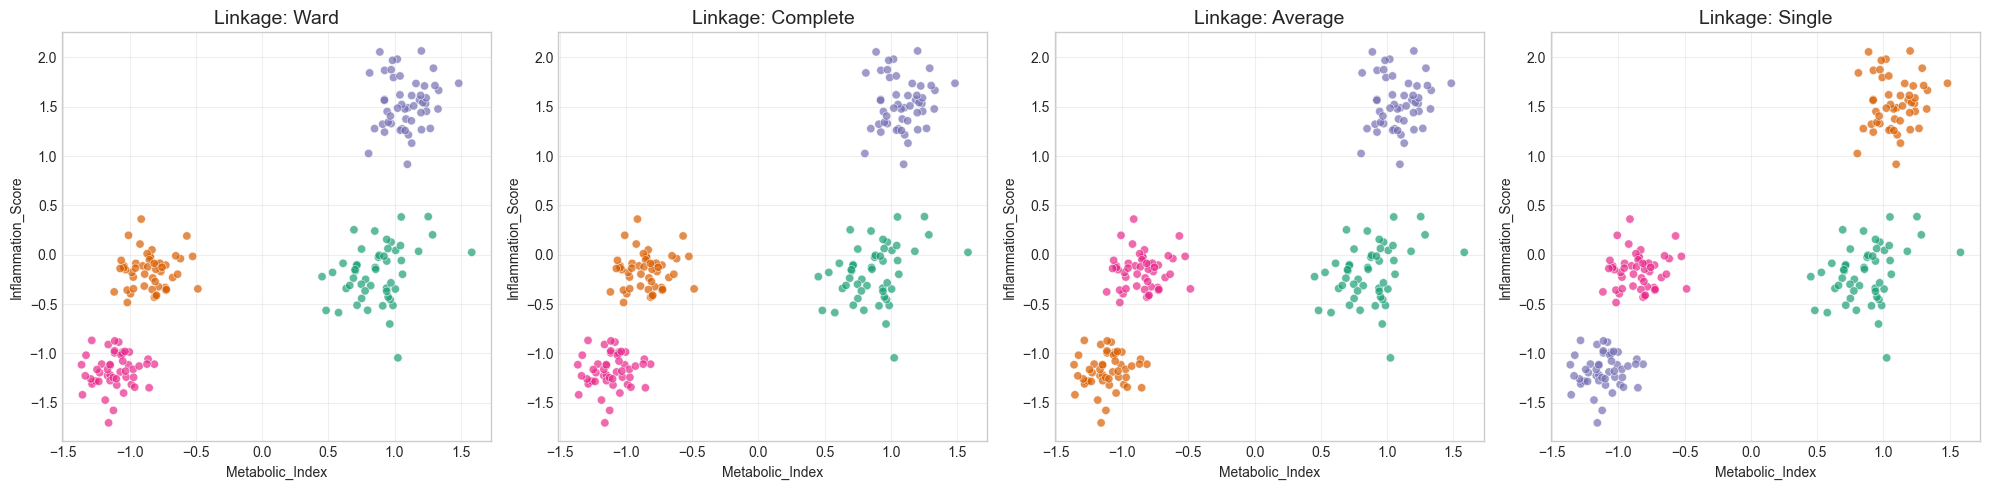

Linkage Comparison Insights:
- Ward and Average successfully find the 4 globular clusters.
- Single linkage often fails on noisy data because a single outlier bridges the gap between clusters, causing the "chaining" effect.


In [8]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, method in enumerate(linkage_methods):
    # Ward only works with Euclidean distance; others can use different metrics
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    temp_labels = model.fit_predict(df_scaled)
    
    sns.scatterplot(x='Metabolic_Index', y='Inflammation_Score', data=df_scaled, 
                    hue=temp_labels, palette='Dark2', ax=axes[i], legend=False, alpha=0.7)
    axes[i].set_title(f'Linkage: {method.capitalize()}', fontsize=14)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Linkage Comparison Insights:')
print('- Ward and Average successfully find the 4 globular clusters.')
print('- Single linkage often fails on noisy data because a single outlier bridges the gap between clusters, causing the "chaining" effect.')

## 11. Extracting Business Profiles
Unsupervised learning is useless without business context. We must calculate the centroids (means) of our final clusters to name and profile them for stakeholders.

In [9]:
cluster_profiles = df_patients.groupby('Cluster').mean().round(1)
cluster_counts = df_patients['Cluster'].value_counts().sort_index()
cluster_profiles['Patient_Count'] = cluster_counts

print('--- Patient Segment Profiles ---')
print(cluster_profiles)

print('\n--- Strategic Profiling ---')
print('Cluster X: Low Metabolism, Low Inflammation -> "Optimal Health"')
print('Cluster Y: Low Metabolism, Moderate Inflammation -> "Early Warning / At Risk"')
print('Cluster Z: High Metabolism, Moderate Inflammation -> "Metabolic Syndrome"')
print('Cluster W: High Metabolism, High Inflammation -> "Severe Critical Risk"')
print('(Note: Actual cluster numbers 0-3 may vary based on random initialization order)')

--- Patient Segment Profiles ---
         Metabolic_Index  Inflammation_Score  Patient_Count
Cluster                                                    
0                   60.6                29.9             50
1                   24.9                30.3             50
2                   65.1                55.7             50
3                   19.3                15.1             50

--- Strategic Profiling ---
Cluster X: Low Metabolism, Low Inflammation -> "Optimal Health"
Cluster Y: Low Metabolism, Moderate Inflammation -> "Early Warning / At Risk"
Cluster Z: High Metabolism, Moderate Inflammation -> "Metabolic Syndrome"
Cluster W: High Metabolism, High Inflammation -> "Severe Critical Risk"
(Note: Actual cluster numbers 0-3 may vary based on random initialization order)


## 12. Advanced Visualization: Seaborn Clustermap
Seaborn provides an incredibly powerful tool called `clustermap`. It performs hierarchical clustering on both the rows (patients) and the columns (features) simultaneously, displaying a color-coded heatmap with dendrograms on the margins.

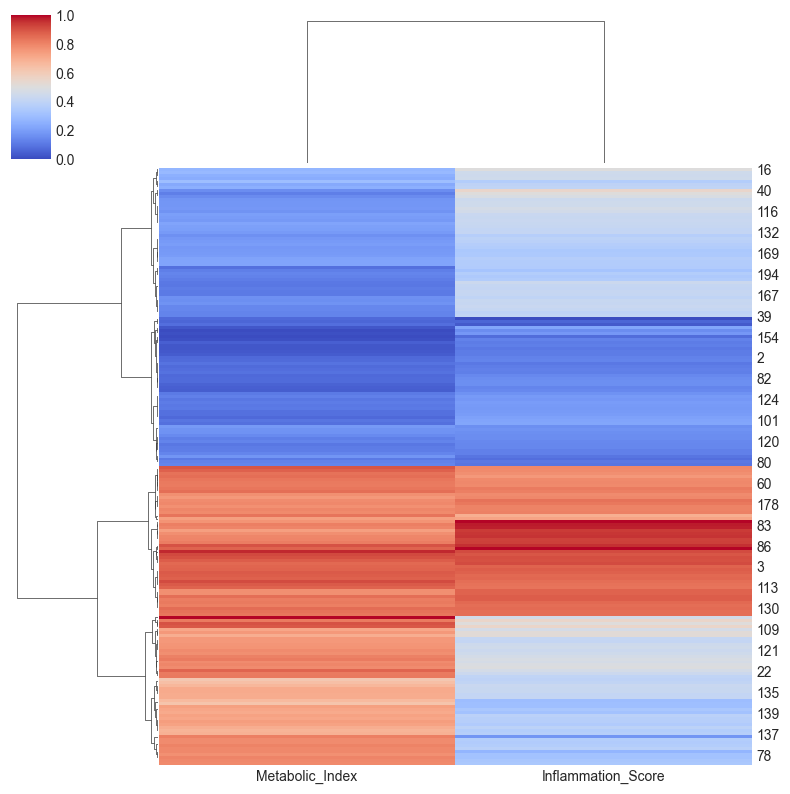

Reading the Clustermap:
- The left dendrogram groups similar patients (rows).
- The top dendrogram groups similar features (columns).
- The colors show the standardized feature intensity for each patient.
- This is heavily used in bioinformatics (e.g., gene expression analysis).


In [10]:
# We use the standardized data for the clustermap
sns.clustermap(df_scaled, method='ward', metric='euclidean', 
               cmap='coolwarm', figsize=(8, 8), standard_scale=1)
plt.show()

print('Reading the Clustermap:')
print('- The left dendrogram groups similar patients (rows).')
print('- The top dendrogram groups similar features (columns).')
print('- The colors show the standardized feature intensity for each patient.')
print('- This is heavily used in bioinformatics (e.g., gene expression analysis).')

## 13. Practice Exercises: Regional Store Segmentation
**Scenario:** You are analyzing 100 retail stores based on two scaled metrics: `Annual_Revenue` and `Foot_Traffic`. You need to build a hierarchy of these stores to present regional management strategies.

In [11]:
# Generate Practice Data
rev_a = np.random.normal(10, 2, 33)
foot_a = np.random.normal(10, 2, 33)

rev_b = np.random.normal(30, 3, 33)
foot_b = np.random.normal(30, 3, 33)

rev_c = np.random.normal(10, 2, 34)
foot_c = np.random.normal(40, 3, 34)

df_stores = pd.DataFrame({
    'Revenue': np.concatenate([rev_a, rev_b, rev_c]),
    'Foot_Traffic': np.concatenate([foot_a, foot_b, foot_c])
})

scaler_store = StandardScaler()
df_stores_scaled = pd.DataFrame(scaler_store.fit_transform(df_stores), columns=df_stores.columns)
print('Practice Store Dataset Created.')

Practice Store Dataset Created.


### Exercise 1: Build the Dendrogram
1. Calculate the linkage matrix using the 'average' method.
2. Plot the dendrogram. Do you see 3 distinct clusters?

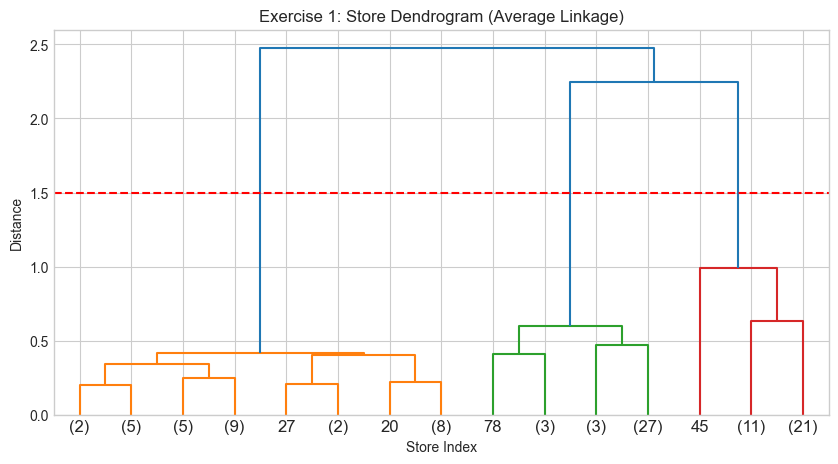

Solution: Yes, the dendrogram clearly branches into 3 massive trunks before merging at the top.


In [12]:
# --- EXERCISE 1 SOLUTION ---
linkage_stores = sch.linkage(df_stores_scaled, method='average')

plt.figure(figsize=(10, 5))
sch.dendrogram(linkage_stores, truncate_mode='level', p=3)
plt.title('Exercise 1: Store Dendrogram (Average Linkage)')
plt.xlabel('Store Index')
plt.ylabel('Distance')
plt.axhline(y=1.5, color='red', linestyle='--')
plt.show()

print('Solution: Yes, the dendrogram clearly branches into 3 massive trunks before merging at the top.')

### Exercise 2: Apply the Model and Extract Profiles
1. Fit an `AgglomerativeClustering` model with K=3 using 'average' linkage.
2. Add labels to the original `df_stores` dataframe.
3. Print the mean values for each cluster.

In [13]:
# --- EXERCISE 2 SOLUTION ---
model_store = AgglomerativeClustering(n_clusters=3, linkage='average')
df_stores['Store_Tier'] = model_store.fit_predict(df_stores_scaled)

store_profiles = df_stores.groupby('Store_Tier').mean().round(1)
print('--- Final Store Profiles ---')
print(store_profiles)
print('\nBusiness Insight: We successfully isolated the High Rev/Traffic stores, the Low Rev/Traffic stores, and the interesting Low Rev/High Traffic stores (prime targets for conversion optimization).')

--- Final Store Profiles ---
            Revenue  Foot_Traffic
Store_Tier                       
0              30.1          29.1
1              10.1           9.6
2              10.0          39.8

Business Insight: We successfully isolated the High Rev/Traffic stores, the Low Rev/Traffic stores, and the interesting Low Rev/High Traffic stores (prime targets for conversion optimization).


## 14. Summary and Key Takeaways

- **Hierarchy over Guesswork:** Unlike K-Means, Hierarchical Clustering doesn't force you to blindly guess K. The Dendrogram acts as a roadmap, showing you the exact distances where merges occur.
- **Agglomerative Process:** Starts with N clusters and merges the closest pairs step-by-step until only 1 cluster remains.
- **Standardization:** Mandatory. Distance metrics (Euclidean) are incredibly sensitive to unscaled data.
- **Linkage Matters:** 'Ward' minimizes variance (good for spherical clusters). 'Single' finds the absolute closest points (prone to chaining). 'Average' and 'Complete' offer balanced alternatives.
- **Computational Cost:** Hierarchical clustering is heavy. It computes an N x N distance matrix, making it slower and more memory-intensive than K-Means for very large datasets.

In [14]:
print("Module 'Hierarchical Clustering' completed successfully.")
print("You now possess the tools to discover nested patterns and build taxonomic trees from raw data!")

Module 'Hierarchical Clustering' completed successfully.
You now possess the tools to discover nested patterns and build taxonomic trees from raw data!
